# 0. Librairies

In [1]:
# Librairies
from scipy.stats import binom
import pickle
import numpy as np
import plotly.graph_objects as go
import healpy as hp
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import xarray as xr
from scipy.optimize import curve_fit
import re

# 2. Démarches mises en oeuvre

## 2.1 Notions de fiabilité et de durée de vie d'un système complexe

### 2.1.4 Association de plusieurs composants pour former un système avec le formalisme k parmi n

Définitions des fonctions 

In [2]:
def harmonic_array(n):
    """Sommes harmoniques cumulées H(1)..H(n)."""
    i = np.arange(1, n + 1)
    return np.cumsum(1 / i)


def somme_inverse(harmonic, n, k):
    """Somme des 1/i pour i de k à n."""
    return harmonic[n - 1] - (harmonic[k - 2] if k > 1 else 0)


def mttf_kn(n, MTTF=1):
    """MTTF_k_n pour k = 1..n-1, à MTTF individuel fixé."""
    harmonic = harmonic_array(n)
    k_values = np.arange(1, n)
    sums = np.array([somme_inverse(harmonic, n, k) for k in k_values])
    return k_values, MTTF * sums



def plot_mttf_individuels(n, MTTF_list):
    """Courbes pour différents MTTF individuels, n fixé."""
    k_values, _ = mttf_kn(n)
    k_pct = k_values / n * 100
    plt.figure()
    for MTTF in MTTF_list:
        _, mttf_values = mttf_kn(n, MTTF)
        plt.plot(k_pct, mttf_values, label=f"MTTF = {MTTF} ans, n = {n}", lw=3)
    plt.xlabel("Proportion de lasers requis pour le fonctionnement (%)", fontsize=15)
    plt.ylabel("MTTF(k,n) [années]", fontsize=15)
    plt.legend()
    plt.grid()
    plt.xlim([20, 100])
    plt.ylim([0, 2.0])
    plt.show()

def reliability_k_of_n(t: np.ndarray, n: int, k: int, lam: float) -> np.ndarray:
    """Fiabilite R(t) d'un systeme k-parmi-n de composants exponentiels iid.

    Parameters
    ----------
    t : temps, array-like (>= 0)
    n : nombre total de composants
    k : nombre minimal de composants fonctionnels requis
    lam : taux de defaillance lambda de chaque composant

    Returns
    -------
    R(t) : array de meme forme que t
    """
    p = np.exp(-lam * t)  # fiabilite d'un composant a l'instant t
    # R(t) = P(X >= k) avec X ~ Binomiale(n, p) = sf(k - 1)
    return binom.sf(k - 1, n, p)


def plot_mttf_redondance(n_list, MTTF=1):
    """Courbes pour différents n (redondance), MTTF individuel fixé."""
    n_ref = min(n_list)
    N = n_ref - 1
    k_pct = np.arange(1, n_ref) / n_ref * 100
    plt.figure()
    for n in n_list:
        _, mttf_values = mttf_kn(n, MTTF)
        plt.plot(k_pct, mttf_values[:N], label=f"MTTF = {MTTF} an, n = {n}", lw=3)
    plt.xlabel("Proportion de lasers requis pour le fonctionnement (%)", fontsize=15)
    plt.ylabel("MTTF(k,n) [années]", fontsize=15)
    plt.legend()
    plt.grid()
    plt.xlim([20, 100])
    plt.ylim([0, 2.0])
    plt.show()

Ce code permet de retrouver les valeurs dans les tables 2.1 et 3.2

In [3]:
# Calcul du MTTF pour un système k parmi n avec un MTTF individuel 
n = 960
k = n-3
lambda_ = 1
MTTF = 1/lambda_

harmonic = harmonic_array(n)
print(f"Le MTTF d'un système {k} parmi {n} pour un MTTF individuel de {MTTF} est "f"{MTTF * somme_inverse(harmonic, n, k):.4g}")

Le MTTF d'un système 957 parmi 960 pour un MTTF individuel de 1.0 est 0.004173


Figure 2.3

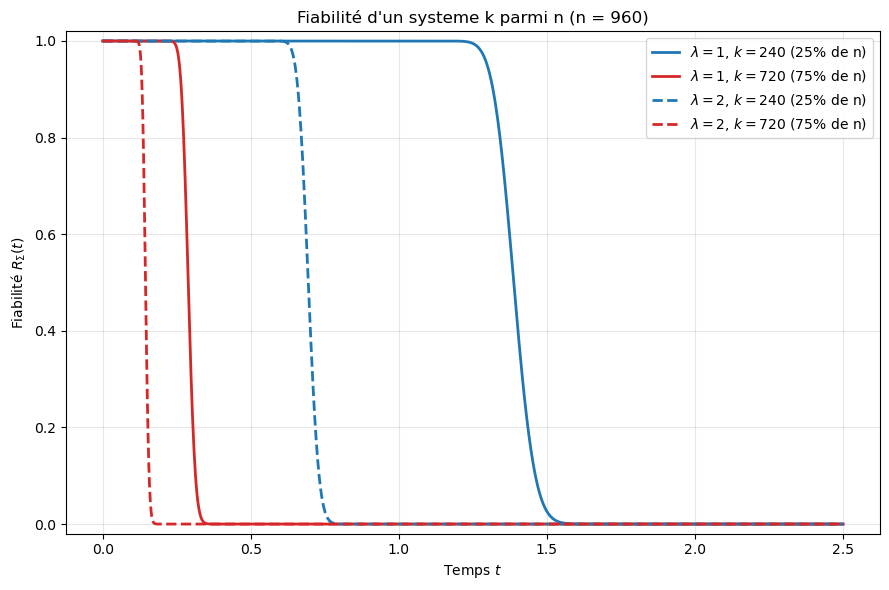

In [4]:
N = 960
LAMBDAS = [1, 2]
K_FRACTIONS = [0.25, 0.75]  # k = 25% de n et k = 75% de n

t = np.linspace(0.0, 2.5, 1000)

fig, ax = plt.subplots(figsize=(9, 6))

styles = {1: "-", 2: "--"}
colors = {0.25: "tab:blue", 0.75: "tab:red"}

for lam in LAMBDAS:
    for frac in K_FRACTIONS:
        k = round(frac * N)
        R = reliability_k_of_n(t, N, k, lam)
        label = rf"$\lambda={lam}$, $k={k}$ ({int(frac * 100)}% de n)"
        ax.plot(t, R, styles[lam], color=colors[frac], label=label, linewidth=2)

ax.set_xlabel("Temps $t$")
ax.set_ylabel(r"Fiabilité $R_{\Sigma}(t)$")
ax.set_title(f"Fiabilité d'un systeme k parmi n (n = {N})")
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

Figure 2.4

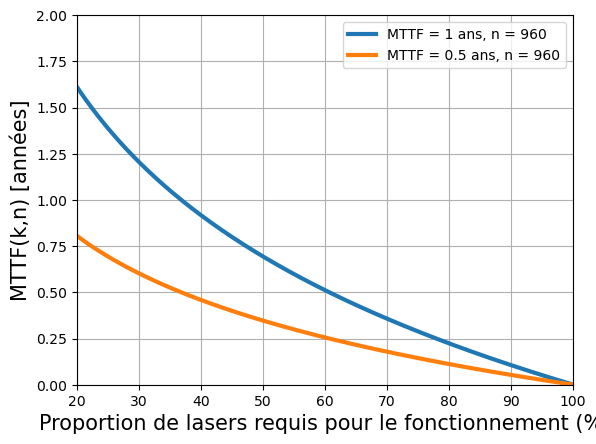

In [5]:
plot_mttf_individuels(n=960, MTTF_list=[1,0.5])

## 2.2 Modélisation de l'irradiation sur cible

### 2.2.1 Utilisation du code de simulation IFRIIT

In [6]:
def visualisation_3D(all_tree, num_tree = 0, num_pert = 0, intensite = False):
    R_int = 2307.0
    R_p0 = 2307.0*2

    #  Données de la sphère d'intensité 
    beam_data = all_tree[num_tree][num_pert]['p_in_z1z2_beam_all']
    intensity = np.array(beam_data['intensity'])
    t_rad = np.array(beam_data['theta'])
    p_rad = np.array(beam_data['phi'])
    X_int = R_int * np.sin(t_rad) * np.cos(p_rad)
    Y_int = R_int * np.sin(t_rad) * np.sin(p_rad)
    Z_int = R_int * np.cos(t_rad)

    # Données de PUISSANCE P0_TW 
    ifriit_list = all_tree[num_tree][num_pert]['ifriit_inputs']
    p0_vals = np.array([b['P0_TW'] for b in ifriit_list])
    t_ifriit_rad = np.radians([b['THETA_DEG'] for b in ifriit_list])
    p_ifriit_rad = np.radians([b['PHI_DEG'] for b in ifriit_list])
    X_p0 = R_p0 * np.sin(t_ifriit_rad) * np.cos(p_ifriit_rad)
    Y_p0 = R_p0 * np.sin(t_ifriit_rad) * np.sin(p_ifriit_rad)
    Z_p0 = R_p0 * np.cos(t_ifriit_rad)

    # Sphère d'intensité
    fig = go.Figure()
    if intensite:
        fig.add_trace(go.Scatter3d(
            x=X_int, y=Y_int, z=Z_int,
            mode='markers',
            marker=dict(
                size=3,
                color=intensity,
                colorscale='Viridis',
                opacity=1.0,  
                showscale=True,
                colorbar=dict(title="Intensité (W/cm²)", x=-0.1)
            ),
            name="Sphère d'intensité",
            hoverinfo='skip'
        ))

    # nuage de points P0_TW 
    fig.add_trace(go.Scatter3d(
        x=X_p0, y=Y_p0, z=Z_p0,
        mode='markers',
        marker=dict(
            size=8,
            color=p0_vals,
            colorscale='YlOrRd',
            opacity=1.0,
            showscale=True,
            colorbar=dict(title="Puissance (TW)", x=1.1),
            line=dict(color='black', width=2)
        ),
        name="Puissance P",
        text=[f"Indice: {i}<br>Puissance P: {p:.2f} TW" for i, p in enumerate(p0_vals)],
        hoverinfo='text'
    ))

    # Mise en page de la figure
    fig.update_layout(
        title="Visualisation : faisceaux globaux encapsulant la sphère d'intensité",
        showlegend=False, 
        scene=dict(
            xaxis=dict(title='X', range=[-R_p0*1.1, R_p0*1.1]),
            yaxis=dict(title='Y', range=[-R_p0*1.1, R_p0*1.1]),
            zaxis=dict(title='Z', range=[-R_p0*1.1, R_p0*1.1]),
            aspectmode='cube'
        ),
        width=900,
        height=700,
        margin=dict(l=0, r=0, b=0, t=50)
    )
    
    fig.show()

In [7]:
with open("results/cas_parfait/all_tree.pkl", "rb") as f:
    all_tree = pickle.load(f)

Figure 2.5.a

In [8]:
visualisation_3D(all_tree, num_tree=0, num_pert=0, intensite=False)

Figure 2.5.b

In [9]:
visualisation_3D(all_tree, num_tree=0, num_pert=0, intensite=True)

### 2.2.2 Métriques d'évaluation

Fonctions pour le tracé des spectres

In [10]:
def read_general_netcdf(filename):
    data = {}
    with xr.open_dataset(filename) as ds:
        for k, v in ds.data_vars.items():
            data[k] = v.values
        for k, v in ds.attrs.items():
            data[k] = v
    return data

def read_data(parameters):
    def imap_norm(intensity_map):
        avg_flux = np.mean(intensity_map)
        return intensity_map / avg_flux - 1.0, avg_flux

    def imap2modes(intensity_map_normalized, lmax):
        modes_complex = hp.sphtfunc.map2alm(intensity_map_normalized, lmax=lmax)
        return modes_complex.real, modes_complex.imag

    LMAX = 30
    illumination_evaluation_radii = 1940.0
    dataset = {}
    intensity_map = parameters["intensity"] * (illumination_evaluation_radii / 10000.0)**2
    intensity_map_normalized, dataset["avg_flux"] = imap_norm(intensity_map)
    dataset["real_modes"], dataset["imag_modes"] = imap2modes(intensity_map_normalized, LMAX)
    complex_modes = dataset["real_modes"] + 1j * dataset["imag_modes"]
    dataset["sigma_l^2"] = alms2power_spectrum(complex_modes, LMAX)
    dataset["sigma_RMS %"] = 100 * np.sqrt(np.sum(dataset["sigma_l^2"]))
    dataset["rms"] = dataset["sigma_RMS %"] / 100
    return dataset

def alms2power_spectrum(alms, LMAX):
    #Cette fonction calcule les $\sigma_{l}^2 / \bar{I}$
    the_modes = np.zeros(LMAX)
    the_modes_full = np.zeros((LMAX,LMAX+1))
    for l in range(LMAX):
        for m in range(l+1):
            the_modes_full[l,m] = np.real(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]*
                np.conjugate(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]))
            if (m>0):
                the_modes[l] = the_modes[l] + 2.*the_modes_full[l,m]
            else:          
                the_modes[l] = the_modes[l] + the_modes_full[l,m]

    the_modes = the_modes / (4.*np.pi)
    return the_modes

def plot_power_spectrum(dataset,i,n,label=None):
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    power_spectrum = alms2power_spectrum(complex_modes, LMAX)
    if label is not None:
        plt.plot(np.arange(1, LMAX), power_spectrum[1:] ,label=label)
    elif i<n:
        plt.plot(np.arange(1, LMAX), power_spectrum[1:], label=f"Nbr faisceaux perdus par tache = {i+1}")


def plot_al(alms):
    ells = np.arange(LMAX + 1)
    
    # Récupère les a_{l,0} qui sont nécessairements réels pour un champ réel
    al0 = np.array([alms[hp.Alm.getidx(LMAX, l, 0)].real for l in ells])
    
    # Applique le facteur
    al = al0* np.sqrt((2 * ells + 1) / (4 * np.pi))
    al = al*100
    # Tracé
    plt.plot(ells, al, marker='o', markersize=3, linewidth=1)
    plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.grid(axis = 'both')
    plt.xlabel("Mode l")
    plt.ylabel("$a_l$ en %")
    plt.xlim([0,25.0])
    # plt.ylim([-0.6,0.1])
    
    return al


Figure 2.6

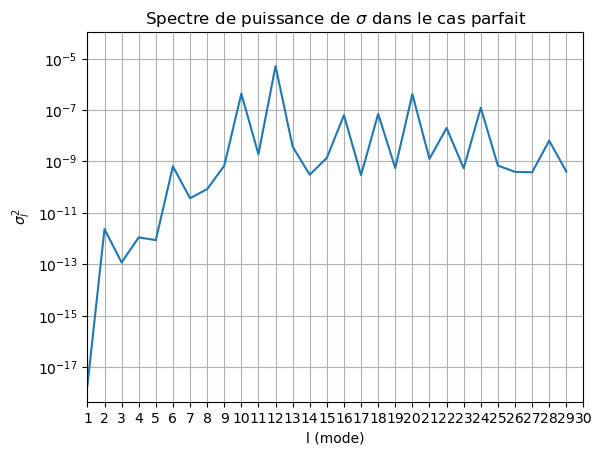

In [11]:
with open("results/cas_parfait/all_tree.pkl", "rb") as f:
    data_parfait = pickle.load(f)
dataset_parfait = data_parfait[0][0]['dataset'] 

LMAX = 30

fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([0, LMAX])
plt.title(r"Spectre de puissance de $\sigma$ dans le cas parfait")
plt.xlabel("l (mode)")
plt.ylabel(r"$\sigma_l^2$")

plot_power_spectrum(dataset_parfait, 0, 1)

plt.grid()
plt.yscale('log')
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5)
plt.xlim([1, LMAX])
plt.xticks(np.arange(1, LMAX+1, 1))
plt.show()

# 3. Résultats

## 3.1 Validation du code avec le cas parfait

Figure 3.1.a

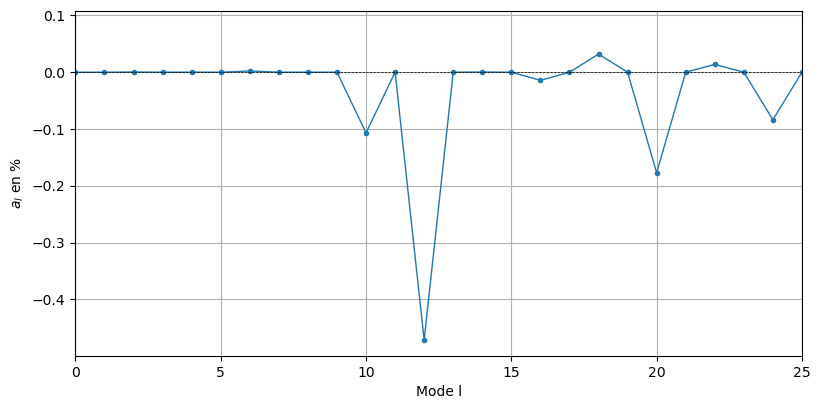

In [12]:
plt.figure(figsize=(8, 4))
real_modes = dataset_parfait["real_modes"]
imag_modes = dataset_parfait["imag_modes"]
alms = real_modes + 1j * imag_modes
plot_al(alms)
plt.show()

## 3.2 Cas avec bruit gaussien

Figure 3.2

In [13]:
# Chargement des données (~ 10 secondes)
directory = "results/cas_gaussien"
liste_dicts = []
for fichier in sorted(glob.glob(os.path.join(directory, "*.pkl"))):
    with open(fichier, "rb") as f:
        liste_dicts.append(pickle.load(f))

n = len(liste_dicts)
print(f"Nombre de fichiers .pkl chargés : {n}")

Nombre de fichiers .pkl chargés : 1


Nombre d'arbres : 1 Nombre de perturbations : 1000


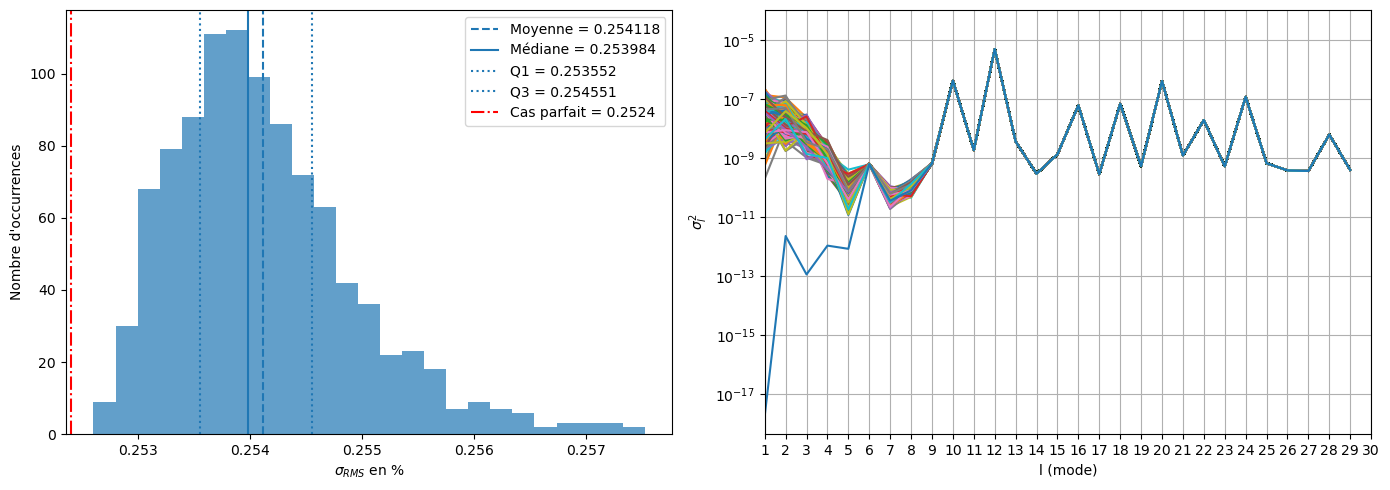

In [14]:
sigma_rms_parfait = round(dataset_parfait['rms'] * 100, 4)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


plt.sca(ax2)
sigma_rms = []
for i in range(n):
    for j in range(len(liste_dicts[i])):
        for k in range(len(liste_dicts[i][j])):
            dataset = liste_dicts[i][j][k]['dataset']
            sigma_rms.append(dataset['rms'] * 100)
            plot_power_spectrum(dataset, i, n)

print(f"Nombre d'arbres : {j + 1}", f"Nombre de perturbations : {k + 1}")
plot_power_spectrum(dataset_parfait, n, n, label="Parfait")


mean = np.mean(sigma_rms)
median = np.median(sigma_rms)
q1 = np.percentile(sigma_rms, 25)
q3 = np.percentile(sigma_rms, 75)


ax1.hist(sigma_rms, bins='auto', alpha=0.7)
ax1.axvline(mean, linestyle='--', label=f'Moyenne = {mean:.6f}')
ax1.axvline(median, linestyle='-', label=f'Médiane = {median:.6f}')
ax1.axvline(q1, linestyle=':', label=f'Q1 = {q1:.6f}')
ax1.axvline(q3, linestyle=':', label=f'Q3 = {q3:.6f}')
ax1.axvline(sigma_rms_parfait, color='red', linestyle='-.',
            label=f'Cas parfait = {sigma_rms_parfait}')
ax1.set_xlabel(r'$\sigma_{RMS}$ en %')
ax1.set_ylabel("Nombre d'occurrences")
ax1.legend()


# ax2.set_title(r"Spectre de puissance de $\sigma$ avec des puissances gaussiennes sur les faisceaux")
ax2.set_xlabel("l (mode)")
ax2.set_ylabel(r"$\sigma_l^2$")
ax2.grid()
ax2.set_yscale('log')
ax2.set_xlim([1, LMAX])
ax2.set_xticks(np.arange(1, LMAX + 1, 1))
ymin, ymax = ax2.get_ylim()
ax2.set_ylim(ymin, ymax * 5)

fig.tight_layout()

# fig.savefig("figure_sigma_rms.pdf", dpi=300, bbox_inches='tight')

plt.show()

## 3.3 Cas de pertes aléatoires de faisceaux

### 3.3.1 Étude statistique

Figure 3.4

In [15]:
def gaussienne(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

directory = "results/50pert500tree/"

with open(directory + "depth_values_1.pkl", "rb") as f:
    depth_values_1 = pickle.load(f)

with open(directory + "depth_values_2.pkl", "rb") as f:
    depth_values_2 = pickle.load(f)

depth_values = depth_values_1 + depth_values_2
depth_values = depth_values
depths, occurrences = np.unique(depth_values, return_counts=True)

# Valeurs initiales pour aider la convergence
p0 = [occurrences.max(), np.average(depths, weights=occurrences), np.std(depths)]

params, cov = curve_fit(gaussienne, np.concatenate([np.linspace(1,6,6), depths]), np.concatenate([np.zeros(6), occurrences]), p0=p0)
a_fit, mu_fit, sigma_fit = params

# Courbe lissée pour l'affichage
x_fit = np.linspace(depths.min(), depths.max(), 200)
y_fit = gaussienne(x_fit, *params)


fig = go.Figure()
seuil = 0.01
fig.add_trace(go.Bar(
    x=depths,
    y=occurrences,
    marker=dict(
        color=occurrences,          # Colore la barre selon le nombre d'occurrences
        colorscale='Plasma',        # Palette de couleur distincte
        line=dict(color='black', width=1)
    ),
    text=occurrences,               # Affiche le nombre directement sur/au-dessus de la barre
    textposition='auto',
))

fig.add_trace(go.Scatter(
    x=x_fit,
    y=y_fit,
    mode='lines',
    line=dict(color='red', width=2),
))

print(f"Paramètres de la gaussienne ajustée: a={a_fit:.2f}, μ={mu_fit:.2f}, σ={sigma_fit:.2f}")
# Configuration du layout
fig.update_layout(
    title=r"$\text{Distribution des profondeurs d'arbres pour } \sigma_{RMS} > 1\%$",
    xaxis=dict(
        title="Nombre de perturbations dans un arbre/profondeur",
        tickmode='linear',          # Force l'affichage de chaque entier sur l'axe X
        dtick=1
    ),
    yaxis=dict(
        title="Nombre d'arbres défaillants"
    ),
    width=800,
    height=500,
    template="plotly_white",
    showlegend=False
)


fig.show()


Paramètres de la gaussienne ajustée: a=25.57, μ=21.79, σ=7.55


### 3.3.2 Réalisation d'un tirage aléatoire avec compensation

Figure 3.5

In [16]:
cas = "_aleatoire"
directory = f"results/realisation{cas}"

liste_dicts = []

### Lecture des fichiers .pkl dans le répertoire courant
for fichier in sorted(glob.glob(os.path.join(directory, "*.pkl"))):
    with open(fichier, "rb") as f:
        data = pickle.load(f)
        liste_dicts.append(data)

### Lecture du fichier contenant les intensités compensées .nc
p_in_z1z2_beam_all = read_general_netcdf(directory + "/p_in_z1z2_beam_all_opti"+ cas +".nc")
dataset_compensated = read_data(p_in_z1z2_beam_all)

n = len(liste_dicts)
print(f"Nombre de fichiers .pkl chargés : {n}")


visualisation_3D(data, num_tree=0, num_pert=0, intensite=True)

Nombre de fichiers .pkl chargés : 1


Figure 3.6

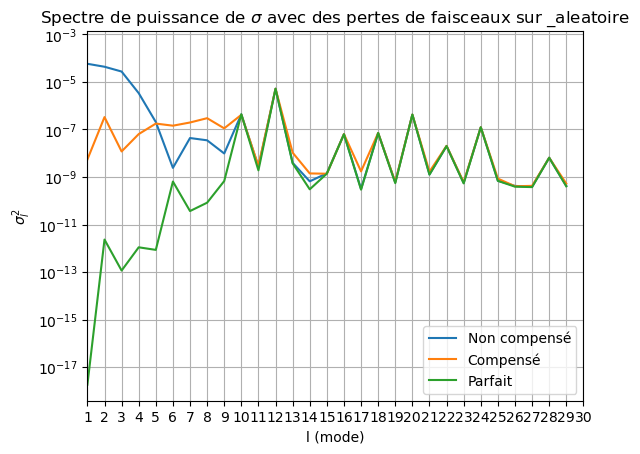

In [17]:
fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([0, LMAX])
plt.title(r"Spectre de puissance de $\sigma$ avec des pertes de faisceaux sur " + cas)
plt.xlabel("l (mode)")
plt.ylabel(r"$\sigma_l^2$")


for i in range(n):
    for j in range(len(liste_dicts[i])):
        for k in range(len(liste_dicts[i][j])):
            dataset = liste_dicts[i][j][k]['dataset'] 
            plot_power_spectrum(dataset,i,n,label="Non compensé")

plot_power_spectrum(dataset_compensated,n,n, label="Compensé")

plot_power_spectrum(dataset_parfait,n,n,label="Parfait")

plt.legend()
plt.legend(loc='lower right')
plt.grid()
plt.yscale('log')
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5)
plt.xlim([1, LMAX])
plt.xticks(np.arange(1, LMAX+1, 1))
plt.show()


## 3.4 Perte de faisceaux localisés

Figures 3.7.X et 3.8.X (X allant de 1 à 4)

Pour visualiser le cas localisé d'intérêt il suffit de mettre 
cas =
- 1tache
- 2taches
- 3taches
- 5taches

Nombre de fichiers .pkl chargés : 2


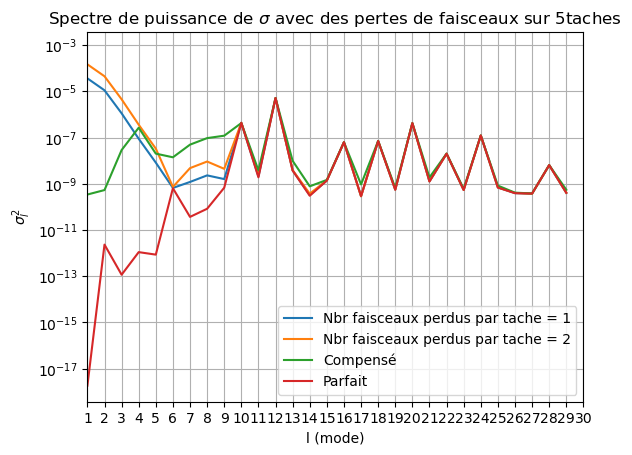

In [18]:
cas = "5taches"

directory = f"results/{cas}"

liste_dicts = []

### Lecture des fichiers .pkl dans le répertoire courant
for fichier in sorted(glob.glob(os.path.join(directory, "*.pkl"))):
    with open(fichier, "rb") as f:
        data = pickle.load(f)
        liste_dicts.append(data)

### Lecture du fichier contenant les intensités compensées .nc
p_in_z1z2_beam_all = read_general_netcdf(directory + "/p_in_z1z2_beam_all_opti"+ cas +"_sansP0.nc")
dataset_compensated = read_data(p_in_z1z2_beam_all)
n = len(liste_dicts)
print(f"Nombre de fichiers .pkl chargés : {n}")

visualisation_3D(data, num_tree=0, num_pert=0, intensite=True)

fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([0, LMAX])
plt.title(r"Spectre de puissance de $\sigma$ avec des pertes de faisceaux sur " + cas)
plt.xlabel("l (mode)")
plt.ylabel(r"$\sigma_l^2$")


for i in range(n):
    for j in range(len(liste_dicts[i])):
        for k in range(len(liste_dicts[i][j])):
            dataset = liste_dicts[i][j][k]['dataset'] 
            plot_power_spectrum(dataset,i,n)

plot_power_spectrum(dataset_compensated,n,n, label="Compensé")

plot_power_spectrum(dataset_parfait,n,n,label="Parfait")

plt.legend()
plt.legend(loc='lower right')
plt.grid()
plt.yscale('log')
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5)
plt.xlim([1, LMAX])
plt.xticks(np.arange(1, LMAX+1, 1))
plt.show()

## 3.5 Étude du comportement de l'algorithme d'optimisation

## 3.5.1 Analyse de la compensation par l'algorithme d'optimisation

Figure 3.9.a

In [19]:
def parse_beam_params(filepath):
    beams = []
    keys = {"P0_TW", "THETA_DEG", "PHI_DEG", "FOC_UM"}
    with open(filepath, "r") as f:
        content = f.read()
    for block in re.findall(r"&BEAM(.*?)/", content, re.DOTALL):
        beam = {}
        for key in keys:
            if key == "FOC_UM":
                # capture toute la liste de valeurs sur la ligne (séparées par des virgules)
                match = re.search(rf"{key}\s*=\s*([\-\d\.dDeE,\s]+)", block)
                if match:
                    raw_values = match.group(1).strip().rstrip(",").split(",")
                    beam[key] = [
                        float(v.strip().replace("d", "e").replace("D", "e"))
                        for v in raw_values if v.strip()
                    ]
            else:
                match = re.search(rf"{key}\s*=\s*([\-\d\.dD]+)", block)
                if match:
                    beam[key] = float(match.group(1).replace("d", "e").replace("D", "e"))
        beams.append(beam)
    return beams  # liste de 30 dicts


main_dir = "results/1tache"

p_in_z1z2_beam_all = read_general_netcdf(main_dir + "/p_in_z1z2_beam_all_opti1tache_sansP0.nc")
dataset = read_data(p_in_z1z2_beam_all)

with open(main_dir + "/1tache_5faisceaux.pkl", "rb") as f:
    all_tree = pickle.load(f)

dataset_originale = all_tree[0][0]['dataset']
ifriit_inputs_originale = all_tree[0][0]['ifriit_inputs']
ifriit_inputs = parse_beam_params(main_dir + "/ifriit_inputs_opti1tache_sansP0.txt")
NBEAMS = len(ifriit_inputs)

print("sigma_RMS en % avant optimisation = ", dataset_originale["rms"]*100)
print("sigma_RMS en % après optimisation = ", dataset["rms"]*100)

def cart2sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return r, theta, phi

idx = np.arange(NBEAMS)

# --- Coordonnées cartésiennes (avant / après) ---
x1 = np.array([ifriit_inputs_originale[i]['FOC_UM'][0] for i in range(NBEAMS)])
y1 = np.array([ifriit_inputs_originale[i]['FOC_UM'][1] for i in range(NBEAMS)])
z1 = np.array([ifriit_inputs_originale[i]['FOC_UM'][2] for i in range(NBEAMS)])

x2 = np.array([ifriit_inputs[i]['FOC_UM'][0] for i in range(NBEAMS)])
y2 = np.array([ifriit_inputs[i]['FOC_UM'][1] for i in range(NBEAMS)])
z2 = np.array([ifriit_inputs[i]['FOC_UM'][2] for i in range(NBEAMS)])

# --- Puissances (avant / après) ---
P0_1 = np.array([ifriit_inputs_originale[i]['P0_TW'] for i in range(NBEAMS)])
P0_2 = np.array([ifriit_inputs[i]['P0_TW'] for i in range(NBEAMS)])

# --- Coordonnées sphériques (avant / après), calculées une seule fois ---
r1, theta1, phi1 = cart2sph(x1, y1, z1)
r2, theta2, phi2 = cart2sph(x2, y2, z2)

# --- Deltas ---
delta_x = x2 - x1
delta_y = y2 - y1
delta_z = z2 - z1
delta_P0 = P0_2 - P0_1
delta_r = r2 - r1
delta_theta = theta2 - theta1
delta_phi = phi2 - phi1

max_abs_delta = np.max(np.abs(delta_r))

fig2 = go.Figure(data=go.Scatter(
    x=np.degrees(phi1),
    y=np.degrees(theta1),
    mode='markers',
    marker=dict(
        size=12,
        color=delta_r,
        colorscale='RdBu_r',
        cmin=-max_abs_delta,
        cmax=max_abs_delta,
        colorbar=dict(title="Δ rayon (µm)"),
        line=dict(color='black', width=0.5)
    ),
    text=[f"Faisceau {i}<br>Δr = {delta_r[i]:.4f} µm<br>r_avant={r1[i]:.8g}<br>r_après={r2[i]:.8g}"
          for i in range(NBEAMS)],
    hoverinfo='text'
))
fig2.update_layout(
    title="Correction radiale par faisceau — projection (θ, φ)",
    xaxis_title="Phi (azimut, °)",
    yaxis_title="Theta (colatitude, °)",
    yaxis=dict(autorange='reversed'),
    width=900,
    height=600
)
fig2.show()

sigma_RMS en % avant optimisation =  0.996020868948027
sigma_RMS en % après optimisation =  0.26409324754495217


Figure 3.9.b

In [20]:
max_abs_delta = np.max(np.abs(delta_theta))

fig2 = go.Figure(data=go.Scatter(
    x=np.degrees(phi1),
    y=np.degrees(theta1),
    mode='markers',
    marker=dict(
        size=12,
        color=delta_theta,
        colorscale='RdBu_r',
        cmin=-max_abs_delta,
        cmax=max_abs_delta,
        colorbar=dict(title="Δ theta (rad)"),
        line=dict(color='black', width=0.5)
    ),
    text=[f"Faisceau {i}<br>Δtheta = {np.degrees(delta_theta[i]):.4f} °<br>theta_avant={np.degrees(theta1[i]):.6g}<br>theta_après={np.degrees(theta2[i]):.6g}"
          for i in range(NBEAMS)],
    hoverinfo='text'
))
fig2.update_layout(
    title="Correction de colatitude par faisceau — projection (θ, φ)",
    xaxis_title="Phi (azimut, °)",
    yaxis_title="Theta (colatitude, °)",
    yaxis=dict(autorange='reversed'),
    width=900,
    height=600
)
fig2.show()

### 3.5.2 Étude de la sensibilité du $\sigma_{RMS}$ et du spectre aux variations de coordonnées des points focaux

Figure 3.11

Nombre d'arbres : 1 Nombre de perturbations : 100


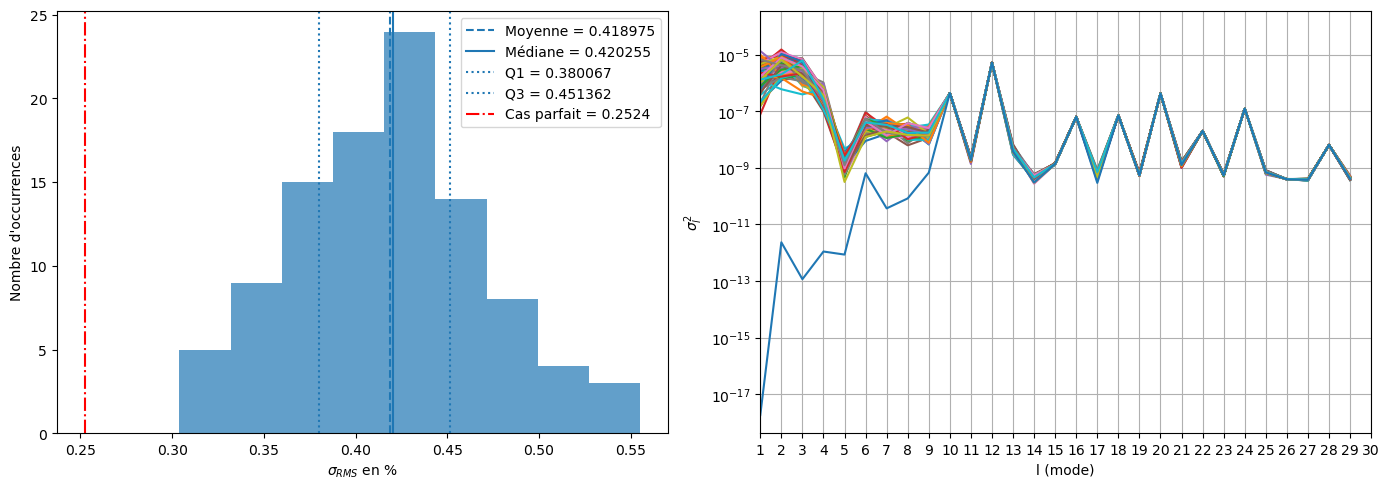

In [21]:
directory = "results/sensibilite_point_foc"

for fichier in sorted(glob.glob(os.path.join(directory, "*.pkl"))):
    with open(fichier, "rb") as f:
        all_tree = pickle.load(f)

sigma_rms_parfait = round(dataset_parfait['rms'] * 100, 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(ax2)
sigma_rms = []
for j in range(len(all_tree)):
    for k in range(len(all_tree[j])):
        dataset = all_tree[j][k]['dataset']
        sigma_rms.append(dataset['rms'] * 100)
        plot_power_spectrum(dataset, 0, 1, label="Non compensé")
print(f"Nombre d'arbres : {j + 1}", f"Nombre de perturbations : {k + 1}")
plot_power_spectrum(dataset_parfait, 0, 1, label="Parfait")


mean = np.mean(sigma_rms)
median = np.median(sigma_rms)
q1 = np.percentile(sigma_rms, 25)
q3 = np.percentile(sigma_rms, 75)


ax1.hist(sigma_rms, bins='auto', alpha=0.7)
ax1.axvline(mean, linestyle='--', label=f'Moyenne = {mean:.6f}')
ax1.axvline(median, linestyle='-', label=f'Médiane = {median:.6f}')
ax1.axvline(q1, linestyle=':', label=f'Q1 = {q1:.6f}')
ax1.axvline(q3, linestyle=':', label=f'Q3 = {q3:.6f}')
ax1.axvline(sigma_rms_parfait, color='red', linestyle='-.',
            label=f'Cas parfait = {sigma_rms_parfait}')
ax1.set_xlabel(r'$\sigma_{RMS}$ en %')
ax1.set_ylabel("Nombre d'occurrences")
ax1.legend()


ax2.set_xlabel("l (mode)")
ax2.set_ylabel(r"$\sigma_l^2$")
ax2.grid()
ax2.set_yscale('log')
ax2.set_xlim([1, LMAX])
ax2.set_xticks(np.arange(1, LMAX + 1, 1))
ymin, ymax = ax2.get_ylim()
ax2.set_ylim(ymin, ymax * 5)

fig.tight_layout()
# fig.savefig("analyse_sensibilite.pdf", dpi=300, bbox_inches='tight')
plt.show()

# 4. Limites de l’étude et perspectives

# 4.2 Solutions proposées pour augmenter le MTTF du système laser

### 4.2.2 Redondance des lignes laser

Figure 4.1

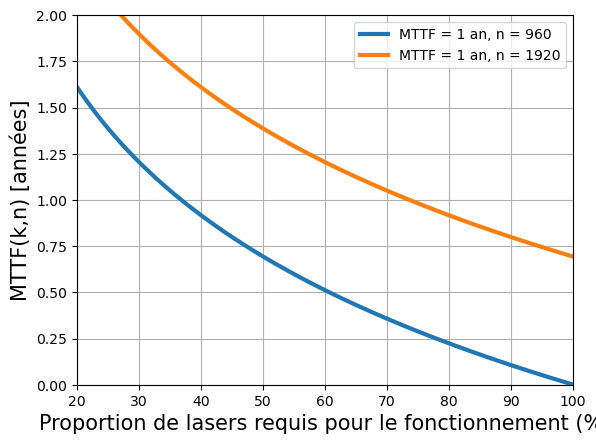

In [22]:
plot_mttf_redondance(n_list=[960, 1920], MTTF=1)

# Annexe

## A9

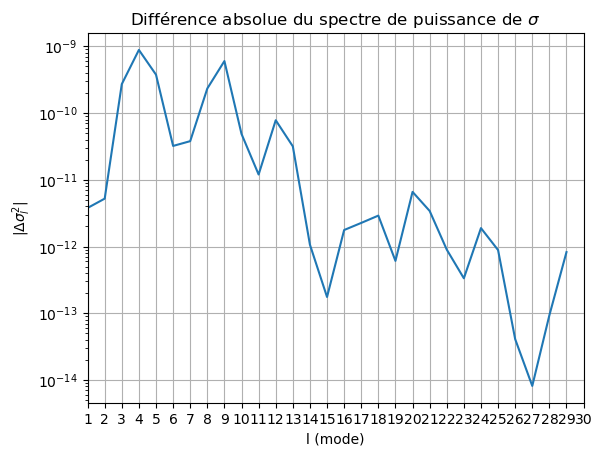

In [23]:
def get_power_spectrum(dataset):
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    return alms2power_spectrum(complex_modes, LMAX)

### Lecture des fichiers
p_in_z1z2_beam_all = read_general_netcdf("results/1tache/p_in_z1z2_beam_all_opti1tache.nc")
dataset_compensated = read_data(p_in_z1z2_beam_all)

p_in_z1z2_beam_all_sansP0 = read_general_netcdf("results/1tache/p_in_z1z2_beam_all_opti1tache_sansP0.nc")
dataset_compensated_sansP0 = read_data(p_in_z1z2_beam_all_sansP0)

LMAX = 30
ps_avec = get_power_spectrum(dataset_compensated)
ps_sans = get_power_spectrum(dataset_compensated_sansP0)
diff_abs = np.abs(ps_avec - ps_sans)

fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([1, LMAX])
plt.title(r"Différence absolue du spectre de puissance de $\sigma$")
plt.xlabel("l (mode)")
plt.ylabel(r"$|\Delta \sigma_l^2|$")
plt.plot(np.arange(1, LMAX), diff_abs[1:])
plt.grid()
plt.yscale('log')
plt.xticks(np.arange(1, LMAX+1, 1))
# plt.savefig("diff_power_spectrum.pdf", dpi=300, bbox_inches='tight')
plt.show()